In [1]:
library(readxl)
library(dplyr)
library(tidyr)
library(stringr)
library(psych)      # PCA / fator
library(scales)
library(lavaan)
library(semTools)

Warning message:
"pacote 'readxl' foi compilado no R versão 4.5.3"

Anexando pacote: 'dplyr'


Os seguintes objetos são mascarados por 'package:stats':

    filter, lag


Os seguintes objetos são mascarados por 'package:base':

    intersect, setdiff, setequal, union


Warning message:
"pacote 'psych' foi compilado no R versão 4.5.3"

Anexando pacote: 'scales'


Os seguintes objetos são mascarados por 'package:psych':

    alpha, rescale


This is lavaan 0.6-21
lavaan is FREE software! Please report any bugs.


Anexando pacote: 'lavaan'


O seguinte objeto é mascarado por 'package:psych':

    cor2cov


 

###############################################################################

This is semTools 0.5-7

All users of R (or SEM) are invited to submit functions or ideas for functions.

###############################################################################


Anexando pacote: 'semTools'


Os seguintes objetos são mascarados por 'package:psych':

    reliability, skew




In [25]:
library(janitor)

ERROR: Error in library(janitor): não há nenhum pacote chamado 'janitor'


In [26]:
library(tibble)

In [31]:
library(scales)

In [2]:
skills <- read_excel("Skills.xlsx")
abilities <- read_excel("Abilities.xlsx")
activities <- read_excel("Work_Activities.xlsx")
styles <- read_excel("Work_Styles.xlsx")

In [8]:
cog_skills <- c(
    "Active Learning",
    "Complex Problem Solving",
    "Critical Thinking",
    "Judgment and Decision Making",
    "Systems Analysis",
    "Systems Evaluation",
    "Operations Analysis",
    "Mathematics",
    "Science",
    "Reading Comprehension",
    "Writing"
  )

cog_abilities <- c(
    "Deductive Reasoning",
    "Inductive Reasoning",
    "Mathematical Reasoning",
    "Problem Sensitivity",
    "Information Ordering",
    "Category Flexibility",
    "Fluency of Ideas",
    "Originality",
    "Memorization",
    "Written Comprehension",
    "Written Expression",
    "Oral Comprehension"
  )

cog_activities <- c(
    "Analyzing Data or Information",
    "Processing Information",
    "Making Decisions and Solving Problems",
    "Thinking Creatively",
    "Interpreting the Meaning of Information for Others",
    "Evaluating Information to Determine Compliance with Standards",
    "Developing Objectives and Strategies",
    "Organizing, Planning, and Prioritizing Work",
    "Updating and Using Relevant Knowledge"
  )

In [16]:
skills_f <- skills %>%
  filter(
    `Element Name` %in% cog_skills,
    `Scale ID` == "LV"
  )

abilities_f <- abilities %>%
  filter(
    `Element Name` %in% cog_abilities,
    `Scale ID` == "LV"
  )

activities_f <- activities %>%
  filter(
    `Element Name` %in% cog_activities,
    `Scale ID` == "LV"
  )

In [17]:
skills_f <- skills_f %>%
  select(`O*NET-SOC Code`, `Element Name`, `Data Value`)

abilities_f <- abilities_f %>%
  select(`O*NET-SOC Code`, `Element Name`, `Data Value`)

activities_f <- activities_f %>%
  select(`O*NET-SOC Code`, `Element Name`, `Data Value`)

In [18]:
data_all <- bind_rows(skills_f, abilities_f, activities_f)

In [19]:
data_wide <- data_all %>%
  pivot_wider(
    names_from = `Element Name`,
    values_from = `Data Value`
  )

In [22]:
dim(data_wide)

[1] 894  33

In [23]:
summary(data_wide)

 O*NET-SOC Code     Reading Comprehension    Writing       Mathematics   
 Length:894         Min.   :1.620         Min.   :1.000   Min.   :0.000  
 Class :character   1st Qu.:3.000         1st Qu.:2.750   1st Qu.:2.000  
 Mode  :character   Median :3.750         Median :3.250   Median :2.500  
                    Mean   :3.653         Mean   :3.311   Mean   :2.558  
                    3rd Qu.:4.120         3rd Qu.:4.000   3rd Qu.:3.120  
                    Max.   :5.880         Max.   :5.750   Max.   :6.000  
    Science      Critical Thinking Active Learning Complex Problem Solving
 Min.   :0.000   Min.   :1.880     Min.   :1.000   Min.   :1.62           
 1st Qu.:0.250   1st Qu.:3.000     1st Qu.:2.620   1st Qu.:2.75           
 Median :1.000   Median :3.750     Median :3.120   Median :3.06           
 Mean   :1.447   Mean   :3.578     Mean   :3.199   Mean   :3.16           
 3rd Qu.:2.500   3rd Qu.:4.000     3rd Qu.:3.880   3rd Qu.:3.75           
 Max.   :5.750   Max.   :5.750  

In [27]:
data_pca <- data_wide %>%
  column_to_rownames("O*NET-SOC Code")

In [28]:
data_scaled <- scale(data_pca)

In [29]:
pca_res <- principal(
  data_scaled,
  nfactors = 1,
  rotate = "none",
  scores = TRUE
)

In [30]:
print(pca_res)

Principal Components Analysis
Call: principal(r = data_scaled, nfactors = 1, rotate = "none", scores = TRUE)
Standardized loadings (pattern matrix) based upon correlation matrix
                                                               PC1   h2   u2
Reading Comprehension                                         0.93 0.86 0.14
Writing                                                       0.90 0.82 0.18
Mathematics                                                   0.76 0.58 0.42
Science                                                       0.73 0.53 0.47
Critical Thinking                                             0.93 0.87 0.13
Active Learning                                               0.94 0.89 0.11
Complex Problem Solving                                       0.94 0.89 0.11
Operations Analysis                                           0.72 0.52 0.48
Judgment and Decision Making                                  0.93 0.87 0.13
Systems Analysis                                    

In [32]:
pca_res$loadings


Loadings:
                                                              PC1  
Reading Comprehension                                         0.930
Writing                                                       0.903
Mathematics                                                   0.763
Science                                                       0.728
Critical Thinking                                             0.934
Active Learning                                               0.943
Complex Problem Solving                                       0.941
Operations Analysis                                           0.720
Judgment and Decision Making                                  0.933
Systems Analysis                                              0.903
Systems Evaluation                                            0.908
Oral Comprehension                                            0.905
Written Comprehension                                         0.928
Written Expression                   

In [33]:
index <- pca_res$scores

In [34]:
data_index <- data_wide %>%
  bind_cols(as.data.frame(index)) %>%
  mutate(
    cognitive_complexity = rescale(PC1, to = c(0,1))
  )

In [35]:
KMO(data_scaled)

Kaiser-Meyer-Olkin factor adequacy
Call: KMO(r = data_scaled)
Overall MSA =  0.98
MSA for each item = 
                                        Reading Comprehension 
                                                         0.98 
                                                      Writing 
                                                         0.98 
                                                  Mathematics 
                                                         0.94 
                                                      Science 
                                                         0.97 
                                            Critical Thinking 
                                                         0.99 
                                              Active Learning 
                                                         0.99 
                                      Complex Problem Solving 
                                                         0.99 
               

Parallel analysis suggests that the number of factors =  NA  and the number of components =  2 


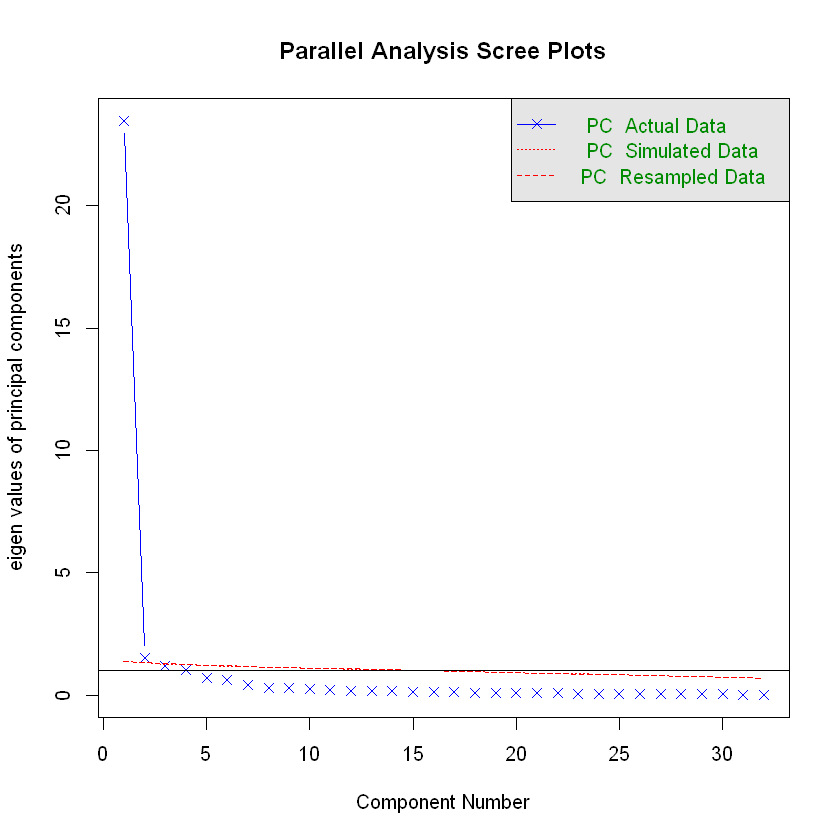

In [36]:
fa.parallel(data_scaled, fa = "pc")

In [37]:
pca_2 <- principal(
  data_scaled,
  nfactors = 2,
  rotate = "varimax",
  scores = TRUE
)

print(pca_2)

Principal Components Analysis
Call: principal(r = data_scaled, nfactors = 2, rotate = "varimax", 
    scores = TRUE)
Standardized loadings (pattern matrix) based upon correlation matrix
                                                               RC1  RC2   h2
Reading Comprehension                                         0.82 0.46 0.88
Writing                                                       0.80 0.44 0.83
Mathematics                                                   0.65 0.41 0.59
Science                                                       0.63 0.38 0.53
Critical Thinking                                             0.82 0.47 0.89
Active Learning                                               0.84 0.45 0.91
Complex Problem Solving                                       0.81 0.49 0.90
Operations Analysis                                           0.70 0.27 0.56
Judgment and Decision Making                                  0.81 0.47 0.88
Systems Analysis                            

In [38]:
pca_1 <- principal(
  data_scaled,
  nfactors = 1,
  rotate = "none",
  scores = TRUE
)

In [39]:
pca_2 <- principal(
  data_scaled,
  nfactors = 2,
  rotate = "varimax",
  scores = TRUE
)

In [40]:
scores_1d <- as.data.frame(pca_1$scores)
scores_2d <- as.data.frame(pca_2$scores)

In [41]:
data_index <- data_wide %>%
  bind_cols(scores_1d, scores_2d) %>%
  rename(
    cognitive_complexity = PC1,
    analytical = RC1,
    applied = RC2
  )

In [42]:
data_index <- data_index %>%
  mutate(
    cognitive_complexity = rescale(cognitive_complexity, to = c(0,1)),
    analytical = rescale(analytical, to = c(0,1)),
    applied = rescale(applied, to = c(0,1))
  )

In [43]:
cor(data_index[, c("cognitive_complexity", "analytical", "applied")])

,cognitive_complexity,analytical,applied
cognitive_complexity,1.0000000,8.021013e-01,5.971880e-01
analytical,0.8021013,1.000000e+00,-4.829937e-16
applied,0.5971880,-4.829937e-16,1.000000e+00


In [44]:
head(data_index, 10)

O*NET-SOC Code,Reading Comprehension,Writing,Mathematics,Science,Critical Thinking,Active Learning,Complex Problem Solving,Operations Analysis,Judgment and Decision Making,⋯,Analyzing Data or Information,Making Decisions and Solving Problems,Thinking Creatively,Updating and Using Relevant Knowledge,Developing Objectives and Strategies,"Organizing, Planning, and Prioritizing Work",Interpreting the Meaning of Information for Others,cognitive_complexity,analytical,applied
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
11-1011.00,4.62,4.38,3.50,0.75,4.75,4.50,4.88,3.88,5.38,⋯,4.84,6.00,4.45,5.09,5.46,5.69,3.38,0.8331226,0.8203474,0.5695219
11-1011.03,4.25,4.25,3.12,1.88,4.12,3.88,4.12,3.12,4.00,⋯,4.81,5.59,4.85,5.59,5.56,6.07,5.00,0.7228959,0.6100719,0.6876533
11-1021.00,4.00,3.88,2.75,0.62,3.88,3.75,3.88,2.38,3.88,⋯,4.27,4.88,3.95,4.17,3.54,4.60,2.92,0.5646261,0.6233383,0.4772978
11-2011.00,4.00,3.88,3.25,0.62,4.12,4.12,3.88,3.12,4.00,⋯,4.06,4.18,4.73,4.49,3.90,5.56,2.90,0.6191961,0.7635200,0.3753180
11-2021.00,4.25,3.88,3.12,1.50,4.25,4.12,3.88,3.62,4.00,⋯,4.04,4.67,4.71,4.52,4.17,5.86,2.98,0.6502984,0.7739688,0.4009166
11-2022.00,4.00,4.00,3.12,0.62,4.00,3.88,3.88,2.62,4.00,⋯,4.81,5.48,4.43,4.71,4.65,5.43,3.57,0.6426661,0.6330473,0.5614298
11-2033.00,3.88,4.00,2.75,0.25,3.88,3.62,3.75,1.88,3.88,⋯,3.94,4.54,4.50,5.04,4.25,5.66,3.13,0.5826957,0.5712373,0.5622976
11-3012.00,4.00,3.75,2.12,0.00,3.88,3.38,3.12,2.50,3.12,⋯,3.74,4.67,4.25,4.99,3.34,5.45,2.75,0.5198861,0.5174072,0.5500588
11-3013.00,3.88,3.75,2.75,0.75,3.75,3.12,3.38,1.38,3.38,⋯,3.92,5.25,4.73,4.76,3.66,5.75,3.71,0.5503012,0.5011981,0.6069505


In [45]:
summary(data_index$cognitive_complexity)
summary(data_index$analytical)
summary(data_index$applied)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.0000  0.3216  0.4767  0.4753  0.6299  1.0000 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.0000  0.3878  0.5010  0.4975  0.6104  1.0000 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.0000  0.4282  0.5288  0.5193  0.6286  1.0000 

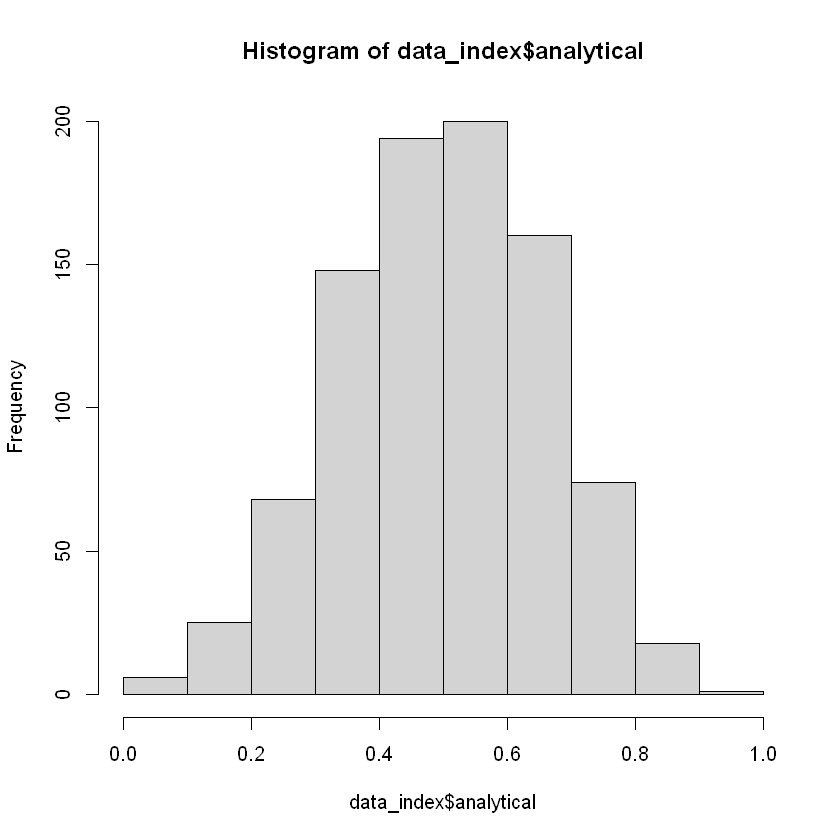

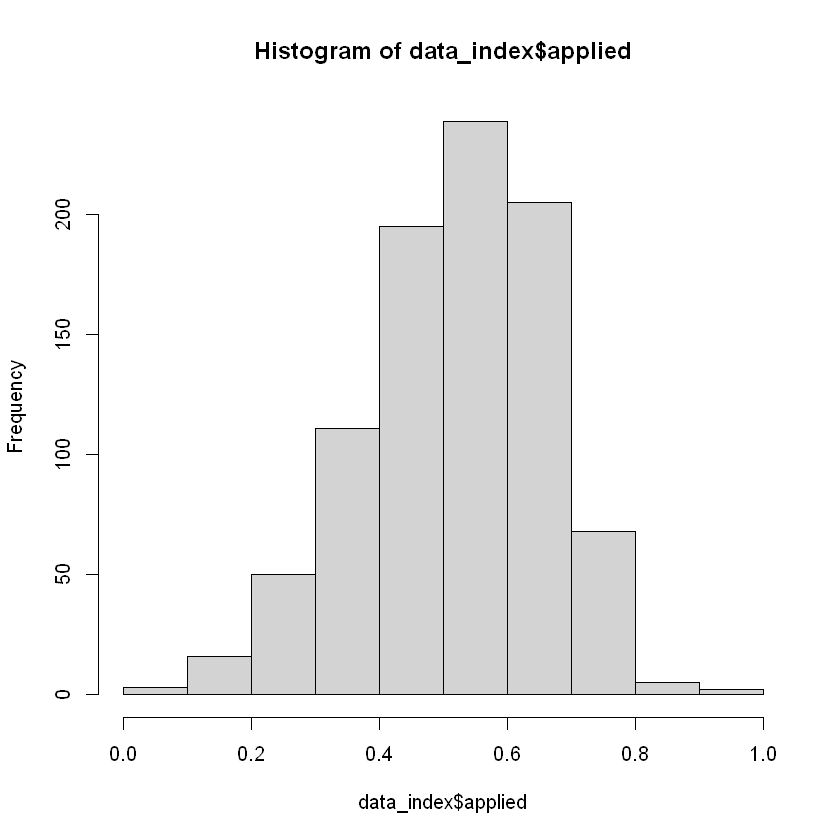

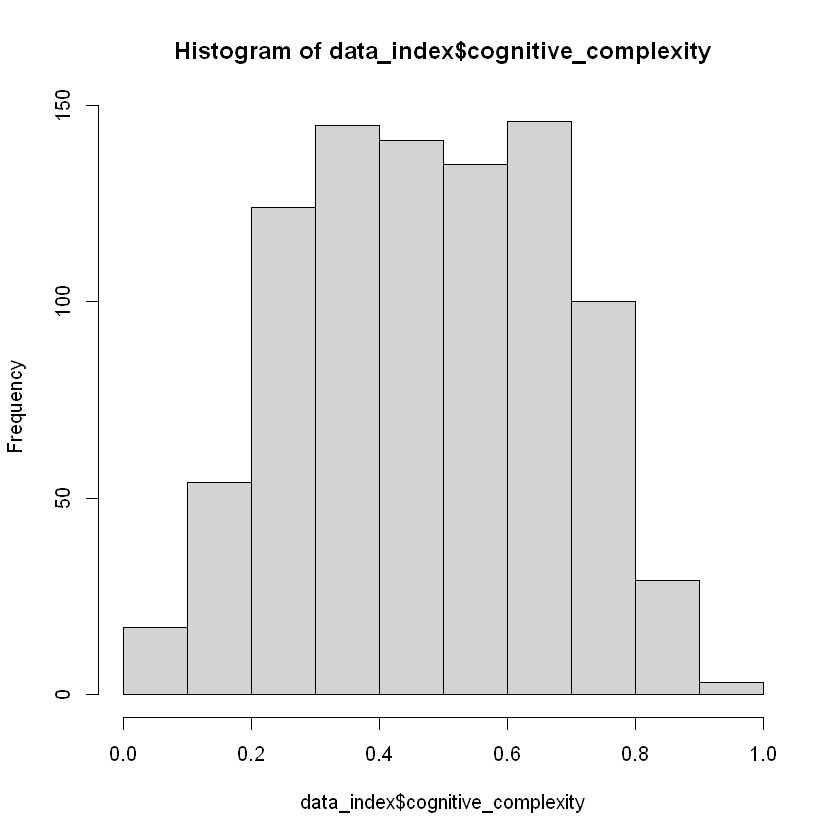

In [46]:
hist(data_index$analytical)
hist(data_index$applied)
hist(data_index$cognitive_complexity)

## EFA

In [47]:
kmo_res <- KMO(data_scaled)
kmo_res

Kaiser-Meyer-Olkin factor adequacy
Call: KMO(r = data_scaled)
Overall MSA =  0.98
MSA for each item = 
                                        Reading Comprehension 
                                                         0.98 
                                                      Writing 
                                                         0.98 
                                                  Mathematics 
                                                         0.94 
                                                      Science 
                                                         0.97 
                                            Critical Thinking 
                                                         0.99 
                                              Active Learning 
                                                         0.99 
                                      Complex Problem Solving 
                                                         0.99 
               

In [48]:
bartlett_res <- cortest.bartlett(data_scaled)
bartlett_res

R was not square, finding R from data



$chisq
[1] 50196.48

$p.value
[1] 0

$df
[1] 496

Parallel analysis suggests that the number of factors =  5  and the number of components =  NA 


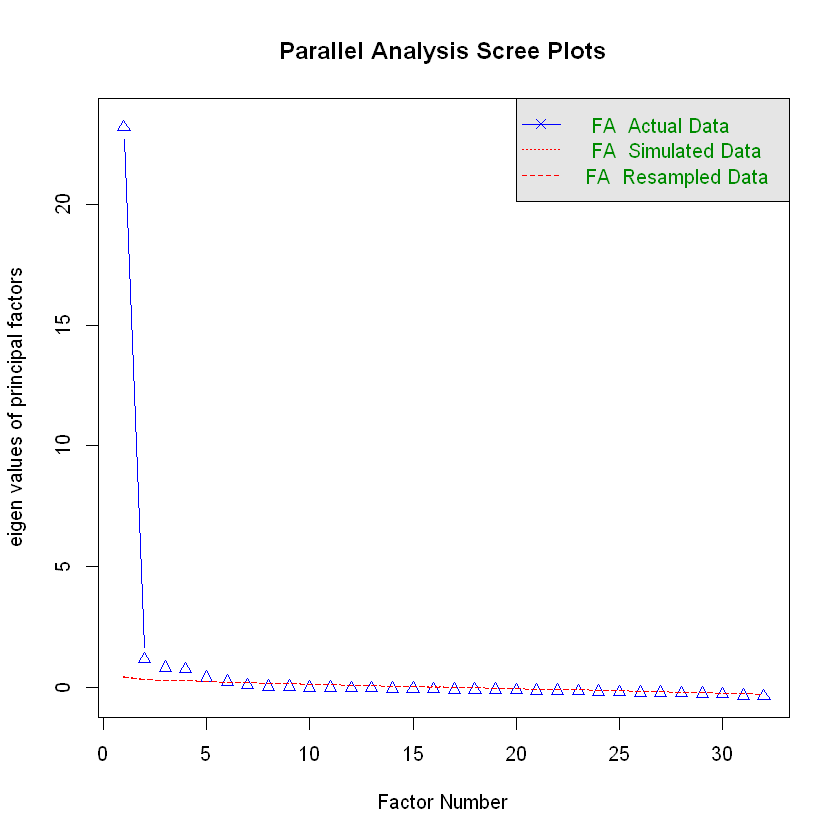

In [49]:
fa.parallel(
  data_scaled,
  fa = "fa",      # importante: "fa", não "pc"
  fm = "ml"       # método consistente com EFA
)


Very Simple Structure
Call: vss(x = x, n = n, rotate = rotate, diagonal = diagonal, fm = fm, 
    n.obs = n.obs, plot = plot, title = title, use = use, cor = cor)
VSS complexity 1 achieves a maximimum of 0.99  with  1  factors
VSS complexity 2 achieves a maximimum of 0.99  with  2  factors

The Velicer MAP achieves a minimum of 0.02  with  5  factors 
BIC achieves a minimum of  1236.86  with  5  factors
Sample Size adjusted BIC achieves a minimum of  2335.7  with  5  factors

Statistics by number of factors 
  vss1 vss2   map dof chisq prob sqresid  fit RMSEA   BIC SABIC complex eChisq
1 0.99 0.00 0.054 464 14117    0     6.6 0.99  0.18 10964 12437     1.0   1609
2 0.63 0.99 0.046 433 11332    0     4.3 0.99  0.17  8389  9765     1.6    919
3 0.49 0.86 0.044 403  9145    0     2.9 0.99  0.16  6407  7687     2.1    545
4 0.29 0.66 0.034 374  6141    0     1.8 1.00  0.13  3599  4787     2.6    244
5 0.26 0.61 0.025 346  3588    0     1.3 1.00  0.10  1237  2336     3.0    114
   SRMR eCR

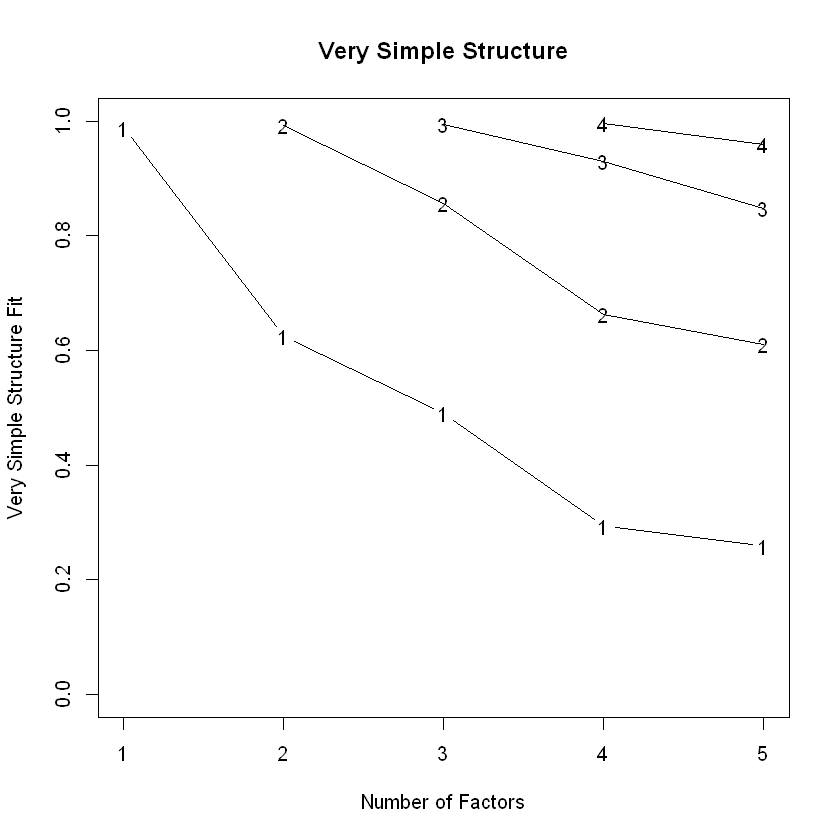

In [50]:
vss_res <- VSS(
  data_scaled,
  n = 5,
  rotate = "varimax"
)

vss_res

In [52]:
efa_2 <- fa(data_scaled, nfactors = 2, fm = "ml", rotate = "oblimin")
efa_5 <- fa(data_scaled, nfactors = 5, fm = "ml", rotate = "oblimin")

In [53]:
efa_2$communality
efa_5$communality

Reading Comprehension 
                                                    0.9585878 
                                                      Writing 
                                                    0.9262867 
                                                  Mathematics 
                                                    0.6115852 
                                                      Science 
                                                    0.5073461 
                                            Critical Thinking 
                                                    0.8979826 
                                              Active Learning 
                                                    0.9082925 
                                      Complex Problem Solving 
                                                    0.9072515 
                                          Operations Analysis 
                                                    0.5640789 
                                 Judgment and Decision Making 
                                                    0.8921399 
                                             Systems Analysis 
                                                    0.8686550 
                                           Systems Evaluation 
                                                    0.8830057 
                                           Oral Comprehension 
                                                    0.8839935 
                                        Written Comprehension 
                                                    0.9524636 
                                           Written Expression 
                                                    0.9514165 
                                             Fluency of Ideas 
                                                    0.8043456 
                                                  Originality 
                                                    0.7495076 
                                          Problem Sensitivity 
                                                    0.7113815 
                                          Deductive Reasoning 
                                                    0.9075476 
                                          Inductive Reasoning 
                                                    0.8679876 
                                         Information Ordering 
                                                    0.7765122 
                                         Category Flexibility 
                                                    0.7271542 
                                       Mathematical Reasoning 
                                                    0.6855410 
                                                 Memorization 
                                                    0.5698855 
                                       Processing Information 
                                                    0.6373153 
Evaluating Information to Determine Compliance with Standards 
                                                    0.3931921 
                                Analyzing Data or Information 
                                                    0.7049215 
                        Making Decisions and Solving Problems 
                                                    0.6525994 
                                          Thinking Creatively 
                                                    0.5158791 
                        Updating and Using Relevant Knowledge 
                                                    0.6503288 
                         Developing Objectives and Strategies 
                                                    0.5981294 
                  Organizing, Planning, and Prioritizing Work 
                                                    0.5867788 
           Interpreting the Meaning of Information for Others 
                                                    0.6637417

Reading Comprehension 
                                                    0.9578809 
                                                      Writing 
                                                    0.9404457 
                                                  Mathematics 
                                                    0.9554588 
                                                      Science 
                                                    0.5931937 
                                            Critical Thinking 
                                                    0.9049172 
                                              Active Learning 
                                                    0.9128680 
                                      Complex Problem Solving 
                                                    0.8997518 
                                          Operations Analysis 
                                                    0.5963861 
                                 Judgment and Decision Making 
                                                    0.8985779 
                                             Systems Analysis 
                                                    0.8471828 
                                           Systems Evaluation 
                                                    0.8627716 
                                           Oral Comprehension 
                                                    0.8846753 
                                        Written Comprehension 
                                                    0.9557887 
                                           Written Expression 
                                                    0.9622524 
                                             Fluency of Ideas 
                                                    0.9537600 
                                                  Originality 
                                                    0.9498933 
                                          Problem Sensitivity 
                                                    0.8737114 
                                          Deductive Reasoning 
                                                    0.9380661 
                                          Inductive Reasoning 
                                                    0.9380707 
                                         Information Ordering 
                                                    0.7967866 
                                         Category Flexibility 
                                                    0.7574813 
                                       Mathematical Reasoning 
                                                    0.9522710 
                                                 Memorization 
                                                    0.5829223 
                                       Processing Information 
                                                    0.8840399 
Evaluating Information to Determine Compliance with Standards 
                                                    0.6436620 
                                Analyzing Data or Information 
                                                    0.9062142 
                        Making Decisions and Solving Problems 
                                                    0.8480793 
                                          Thinking Creatively 
                                                    0.7672987 
                        Updating and Using Relevant Knowledge 
                                                    0.8048701 
                         Developing Objectives and Strategies 
                                                    0.7938932 
                  Organizing, Planning, and Prioritizing Work 
                                                    0.7270455 
           Interpreting the Meaning of Information for Others 
                                                    0.8184159

In [56]:
efa_2$scores
efa_5$scores

,ML1,ML2
11-1011.00,2.0567897,1.54512126
11-1011.03,1.2703298,0.79303038
11-1021.00,0.5957399,0.18173837
11-2011.00,0.8788583,0.64917528
11-2021.00,1.0009875,0.60811659
11-2022.00,0.9079667,0.85085461
11-2033.00,0.5889655,-0.22804842
11-3012.00,0.2612683,-0.52917766
11-3013.00,0.3827159,0.06332338
11-3013.01,0.8305028,0.53694516


,ML1,ML2,ML4,ML3,ML5
11-1011.00,1.3122437,1.31427146,0.74691954,2.08108869,2.49878857
11-1011.03,0.8683849,0.61742086,1.17579148,1.82826565,0.85918920
11-1021.00,0.4855065,0.43825878,-0.06250936,0.72669844,0.58542456
11-2011.00,0.5869004,0.77734914,-0.43344302,1.63924454,0.84900965
11-2021.00,0.7129228,0.91490208,-0.33993139,1.87375059,0.68012222
11-2022.00,0.5428352,0.91109502,0.45587694,1.55509623,0.39135969
11-2033.00,0.6496838,0.40454605,0.14887718,1.65713817,-0.40387335
11-3012.00,0.4431289,-0.25773475,0.19299484,0.49290769,-0.15571713
11-3013.00,0.3259224,0.14247970,0.53668262,0.38055679,0.11870585
11-3013.01,0.5324969,0.06525779,1.21893139,1.37799321,0.78583772


In [57]:
efa_2$STATISTIC
efa_2$dof
efa_2$PVAL

[1] 10913.95

[1] 433

[1] 0

In [58]:
efa_5$STATISTIC
efa_5$dof
efa_5$PVAL

[1] 3348.707

[1] 346

[1] 0

In [59]:
efa_2$Phi

,ML1,ML2
ML1,1.0000000,-0.1335176
ML2,-0.1335176,1.0000000


In [60]:
efa_5$Phi

,ML1,ML2,ML4,ML3,ML5
ML1,1.0000000,0.6959364,0.6065710,0.6302966,0.6339027
ML2,0.6959364,1.0000000,0.5384518,0.4798919,0.5465985
ML4,0.6065710,0.5384518,1.0000000,0.4154656,0.4108926
ML3,0.6302966,0.4798919,0.4154656,1.0000000,0.4101244
ML5,0.6339027,0.5465985,0.4108926,0.4101244,1.0000000



Three factors are required for identification -- general factor loadings set to be equal. 
Proceed with caution. 
Think about redoing the analysis with alternative values of the 'option' setting.




Omega 
Call: omegah(m = m, nfactors = nfactors, fm = fm, key = key, flip = flip, 
    digits = digits, title = title, sl = sl, labels = labels, 
    plot = plot, n.obs = n.obs, rotate = rotate, Phi = Phi, option = option, 
    covar = covar)
Alpha:                 0.99 
G.6:                   0.99 
Omega Hierarchical:    0.87 
Omega H asymptotic:    0.88 
Omega Total            0.99 

Schmid Leiman Factor loadings greater than  0.2 
                                                                 g   F1*   F2*
Reading Comprehension                                         0.85  0.39      
Writing                                                       0.83  0.38      
Mathematics                                                   0.70  0.26      
Science                                                       0.67  0.26      
Critical Thinking                                             0.86  0.39      
Active Learning                                               0.86  0.41      
Complex Pr

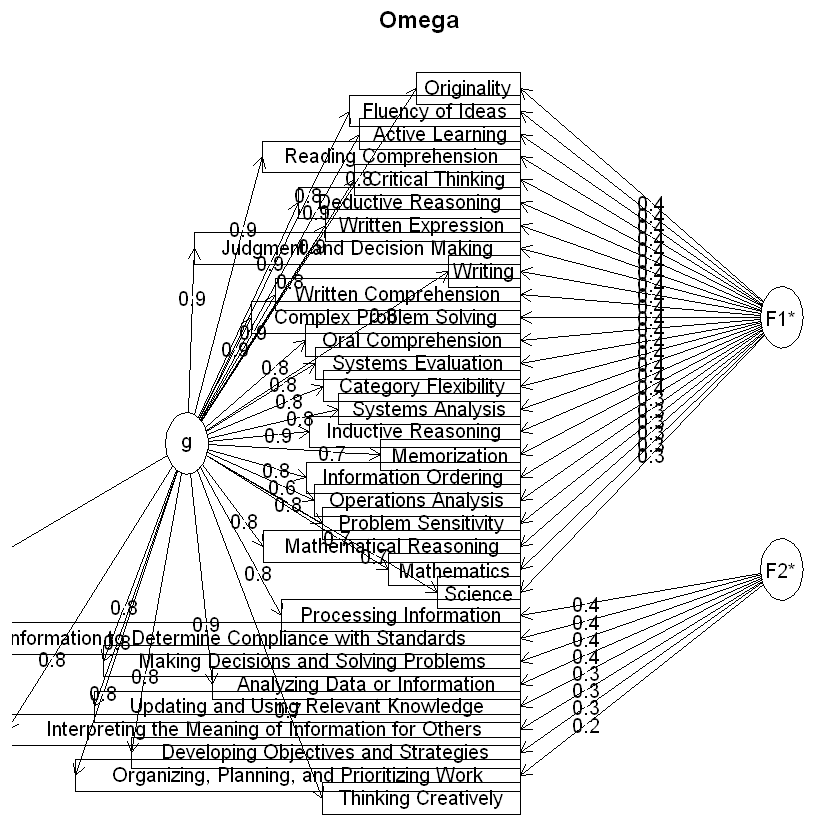

In [61]:
omega_res <- omega(
  data_scaled,
  nfactors = 2   # pode testar 2 também
)

omega_res

Omega 
Call: omegah(m = m, nfactors = nfactors, fm = fm, key = key, flip = flip, 
    digits = digits, title = title, sl = sl, labels = labels, 
    plot = plot, n.obs = n.obs, rotate = rotate, Phi = Phi, option = option, 
    covar = covar)
Alpha:                 0.99 
G.6:                   0.99 
Omega Hierarchical:    0.88 
Omega H asymptotic:    0.89 
Omega Total            0.99 

Schmid Leiman Factor loadings greater than  0.2 
                                                                 g   F1*   F2*
Reading Comprehension                                         0.93  0.30      
Writing                                                       0.91  0.31      
Mathematics                                                   0.72            
Science                                                       0.69            
Critical Thinking                                             0.90  0.20      
Active Learning                                               0.91  0.20      
Complex Pr

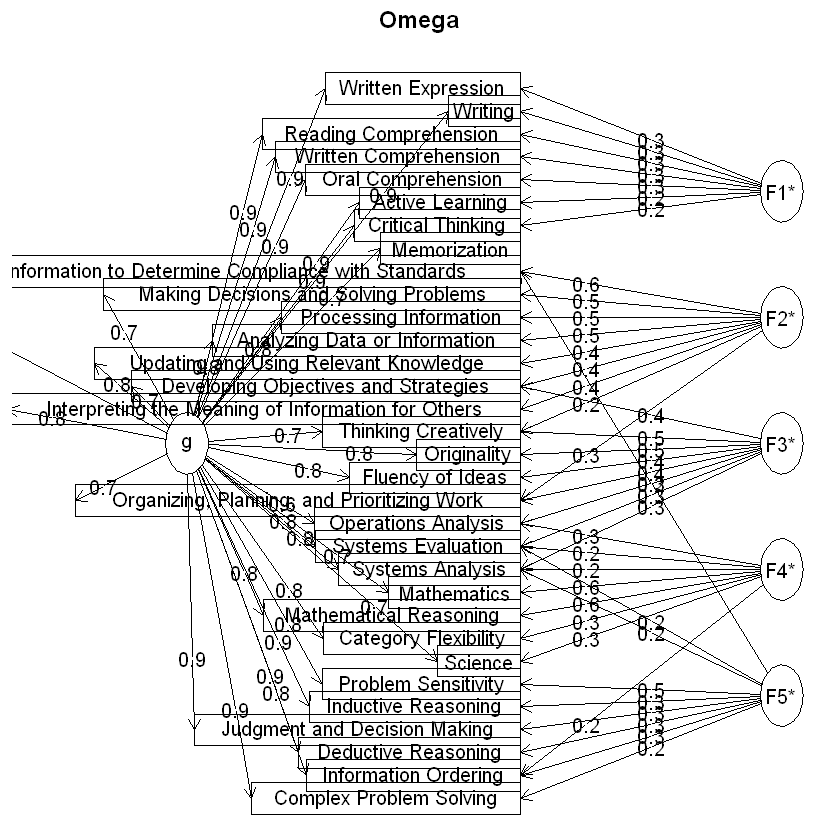

In [62]:
omega_res <- omega(
  data_scaled,
  nfactors = 5   # pode testar 2 também
)

omega_res

## CFA

In [63]:
names(data_scaled) <- make.names(names(data_scaled))

In [64]:
model_1f <- '
g =~ Reading.Comprehension + Writing + Mathematics + Science +
     Critical.Thinking + Active.Learning + Complex.Problem.Solving +
     Operations.Analysis + Judgment.and.Decision.Making +
     Systems.Analysis + Systems.Evaluation +
     Oral.Comprehension + Written.Comprehension + Written.Expression +
     Fluency.of.Ideas + Originality + Problem.Sensitivity +
     Deductive.Reasoning + Inductive.Reasoning +
     Information.Ordering + Category.Flexibility +
     Mathematical.Reasoning + Memorization +
     Processing.Information +
     Evaluating.Information.to.Determine.Compliance.with.Standards +
     Analyzing.Data.or.Information +
     Making.Decisions.and.Solving.Problems +
     Thinking.Creatively +
     Updating.and.Using.Relevant.Knowledge +
     Developing.Objectives.and.Strategies +
     Organizing..Planning..and.Prioritizing.Work +
     Interpreting.the.Meaning.of.Information.for.Others
'

In [65]:
model_2f <- '
analytical =~ Reading.Comprehension + Writing + Mathematics + Science +
              Critical.Thinking + Active.Learning + Complex.Problem.Solving +
              Operations.Analysis + Judgment.and.Decision.Making +
              Systems.Analysis + Systems.Evaluation +
              Oral.Comprehension + Written.Comprehension +
              Written.Expression + Fluency.of.Ideas + Originality +
              Problem.Sensitivity + Deductive.Reasoning +
              Inductive.Reasoning + Information.Ordering +
              Category.Flexibility + Mathematical.Reasoning + Memorization

applied =~ Processing.Information +
           Evaluating.Information.to.Determine.Compliance.with.Standards +
           Analyzing.Data.or.Information +
           Making.Decisions.and.Solving.Problems +
           Thinking.Creatively +
           Updating.and.Using.Relevant.Knowledge +
           Developing.Objectives.and.Strategies +
           Organizing..Planning..and.Prioritizing.Work +
           Interpreting.the.Meaning.of.Information.for.Others
'

In [66]:
model_5f <- '
F1 =~ Reading.Comprehension + Writing + Oral.Comprehension +
      Written.Comprehension + Written.Expression

F2 =~ Deductive.Reasoning + Inductive.Reasoning +
      Mathematical.Reasoning + Mathematics

F3 =~ Fluency.of.Ideas + Originality + Thinking.Creatively

F4 =~ Processing.Information + Analyzing.Data.or.Information +
      Making.Decisions.and.Solving.Problems +
      Evaluating.Information.to.Determine.Compliance.with.Standards

F5 =~ Developing.Objectives.and.Strategies +
      Organizing..Planning..and.Prioritizing.Work +
      Updating.and.Using.Relevant.Knowledge +
      Interpreting.the.Meaning.of.Information.for.Others
'

In [69]:
colnames(data_scaled) <- make.names(colnames(data_scaled))

In [70]:
fit_1f <- lavaan::cfa(model_1f, data = data_scaled, estimator = "MLR")
fit_2f <- lavaan::cfa(model_2f, data = data_scaled, estimator = "MLR")
fit_5f <- lavaan::cfa(model_5f, data = data_scaled, estimator = "MLR")

In [71]:
fitMeasures(fit_1f, c("cfi","tli","rmsea","srmr","bic"))
fitMeasures(fit_2f, c("cfi","tli","rmsea","srmr","bic"))
fitMeasures(fit_5f, c("cfi","tli","rmsea","srmr","bic"))

cfi       tli     rmsea      srmr       bic 
    0.728     0.709     0.182     0.061 44845.150

cfi       tli     rmsea      srmr       bic 
    0.777     0.761     0.165     0.049 42374.668

cfi       tli     rmsea      srmr       bic 
    0.877     0.853     0.162     0.053 24291.872

In [72]:
colnames(data_scaled)

[1] "Reading.Comprehension"                                        
 [2] "Writing"                                                      
 [3] "Mathematics"                                                  
 [4] "Science"                                                      
 [5] "Critical.Thinking"                                            
 [6] "Active.Learning"                                              
 [7] "Complex.Problem.Solving"                                      
 [8] "Operations.Analysis"                                          
 [9] "Judgment.and.Decision.Making"                                 
[10] "Systems.Analysis"                                             
[11] "Systems.Evaluation"                                           
[12] "Oral.Comprehension"                                           
[13] "Written.Comprehension"                                        
[14] "Written.Expression"                                           
[15] "Fluency.of.Ideas"                                             
[16] "Originality"                                                  
[17] "Problem.Sensitivity"                                          
[18] "Deductive.Reasoning"                                          
[19] "Inductive.Reasoning"                                          
[20] "Information.Ordering"                                         
[21] "Category.Flexibility"                                         
[22] "Mathematical.Reasoning"                                       
[23] "Memorization"                                                 
[24] "Processing.Information"                                       
[25] "Evaluating.Information.to.Determine.Compliance.with.Standards"
[26] "Analyzing.Data.or.Information"                                
[27] "Making.Decisions.and.Solving.Problems"                        
[28] "Thinking.Creatively"                                          
[29] "Updating.and.Using.Relevant.Knowledge"                        
[30] "Developing.Objectives.and.Strategies"                         
[31] "Organizing..Planning..and.Prioritizing.Work"                  
[32] "Interpreting.the.Meaning.of.Information.for.Others"

In [75]:
model_bifactor <- '

# Fator geral
g =~ Reading.Comprehension + Writing + Mathematics + Science +
     Critical.Thinking + Active.Learning + Complex.Problem.Solving +
     Operations.Analysis + Judgment.and.Decision.Making +
     Systems.Analysis + Systems.Evaluation +
     Oral.Comprehension + Written.Comprehension + Written.Expression +
     Fluency.of.Ideas + Originality + Problem.Sensitivity +
     Deductive.Reasoning + Inductive.Reasoning +
     Information.Ordering + Category.Flexibility +
     Mathematical.Reasoning + Memorization +
     Processing.Information +
     Evaluating.Information.to.Determine.Compliance.with.Standards +
     Analyzing.Data.or.Information +
     Making.Decisions.and.Solving.Problems +
     Thinking.Creatively +
     Updating.and.Using.Relevant.Knowledge +
     Developing.Objectives.and.Strategies +
     Organizing..Planning..and.Prioritizing.Work +
     Interpreting.the.Meaning.of.Information.for.Others

# Grupo 1: cognitivo clássico
analytical =~ Reading.Comprehension + Writing + Mathematics + Science +
              Critical.Thinking + Active.Learning + Complex.Problem.Solving +
              Operations.Analysis + Judgment.and.Decision.Making +
              Systems.Analysis + Systems.Evaluation +
              Oral.Comprehension + Written.Comprehension +
              Written.Expression + Fluency.of.Ideas + Originality +
              Problem.Sensitivity + Deductive.Reasoning +
              Inductive.Reasoning + Information.Ordering +
              Category.Flexibility + Mathematical.Reasoning + Memorization

# Grupo 2: aplicado
applied =~ Processing.Information +
           Evaluating.Information.to.Determine.Compliance.with.Standards +
           Analyzing.Data.or.Information +
           Making.Decisions.and.Solving.Problems +
           Thinking.Creatively +
           Updating.and.Using.Relevant.Knowledge +
           Developing.Objectives.and.Strategies +
           Organizing..Planning..and.Prioritizing.Work +
           Interpreting.the.Meaning.of.Information.for.Others

# Ortogonalidade (ESSENCIAL no bifactor)
g ~~ 0*analytical
g ~~ 0*applied
analytical ~~ 0*applied
'

In [76]:
fit_bif <- lavaan::cfa(
  model_bifactor,
  data = data_scaled,
  estimator = "MLR"
)

summary(fit_bif, fit.measures = TRUE, standardized = TRUE)

lhs,op,rhs,exo,est,se,z,pvalue,std.lv,std.all
<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
g,=~,Reading.Comprehension,0,1.0000000,0.000000000,NA,NA,0.9461544,0.9466842
g,=~,Writing,0,0.9744795,0.013147173,74.12084,0,0.9220081,0.9225244
g,=~,Mathematics,0,0.7839792,0.033952671,23.09035,0,0.7417654,0.7421802
g,=~,Science,0,0.7471104,0.026606675,28.07981,0,0.7068818,0.7072789
g,=~,Critical.Thinking,0,0.9999682,0.019073369,52.42745,0,0.9461242,0.9466540
g,=~,Active.Learning,0,1.0075298,0.017944824,56.14598,0,0.9532787,0.9538125
g,=~,Complex.Problem.Solving,0,0.9980260,0.026112086,38.22085,0,0.9442867,0.9448156
g,=~,Operations.Analysis,0,0.7542005,0.034414143,21.91542,0,0.7135901,0.7139887
g,=~,Judgment.and.Decision.Making,0,0.9958564,0.025580029,38.93101,0,0.9422339,0.9427616
